In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('../../results/metrics.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget distribution:\n{df['is_high_risk'].value_counts()}")

Dataset shape: (4381, 49)

Columns: ['file_path', 'is_high_risk', 'nargs_fn_nargs', 'nargs_closure_nargs', 'nargs_fn_nargs_sum', 'nargs_closure_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_min', 'nargs_closure_nargs_min', 'nargs_fn_nargs_max', 'nargs_closure_nargs_max', 'nexits_exit', 'nexits_exit_sum', 'nexits_exit_avg', 'nexits_exit_min', 'nexits_exit_max', 'cognitive', 'cognitive_sum', 'cognitive_avg', 'cognitive_min', 'cognitive_max', 'cyclomatic_cyclomatic', 'cyclomatic_cyclomatic_sum', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_min', 'cyclomatic_cyclomatic_max', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_operands', 'halstead_volume', 'halstead_difficulty', 'halstead_level', 'halstead_effort', 'loc_sloc', 'loc_ploc', 'loc_cloc', 'loc_lloc', 'loc_blank', 'mi_mi_original', 'mi_mi_sei', 'mi_mi_visual_studio', 'abc_assignments', 'abc_branches', 'abc_conditions', 'nom_functions', 'nom_closures', 'wmc_cyclomati

In [3]:
target_col = 'is_high_risk'
exclude_cols = ['file_path', target_col]

feature_cols = [col for col in df.columns if col not in exclude_cols]
print(f"\nNumber of features: {len(feature_cols)}")

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

X = df[feature_cols].copy()
y = df[target_col].copy()

X = X.select_dtypes(include=[np.number])
print(f"Numeric features: {list(X.columns)}")

X = X.fillna(X.median())

le = LabelEncoder()
y_encoded = le.fit_transform(y.astype(str))
print(f"\nTarget classes: {le.classes_}")
print(f"Encoded: {dict(zip(le.classes_, range(len(le.classes_))))}")


Number of features: 47
Numeric features: ['nargs_fn_nargs', 'nargs_closure_nargs', 'nargs_fn_nargs_sum', 'nargs_closure_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_min', 'nargs_closure_nargs_min', 'nargs_fn_nargs_max', 'nargs_closure_nargs_max', 'nexits_exit', 'nexits_exit_sum', 'nexits_exit_avg', 'nexits_exit_min', 'nexits_exit_max', 'cognitive', 'cognitive_sum', 'cognitive_avg', 'cognitive_min', 'cognitive_max', 'cyclomatic_cyclomatic', 'cyclomatic_cyclomatic_sum', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_min', 'cyclomatic_cyclomatic_max', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_operands', 'halstead_volume', 'halstead_difficulty', 'halstead_level', 'halstead_effort', 'loc_sloc', 'loc_ploc', 'loc_cloc', 'loc_lloc', 'loc_blank', 'mi_mi_original', 'mi_mi_sei', 'mi_mi_visual_studio', 'abc_assignments', 'abc_branches', 'abc_conditions', 'nom_functions', 'nom_closures', 'wmc_cyclomatic']

Target classes: ['

In [4]:
df_fe = df.copy()

df_fe['operator_operand_ratio'] = df_fe['halstead_operators'] / \
    (df_fe['halstead_operands'] + 1)
df_fe['sloc_per_function'] = df_fe['loc_sloc'] / (df_fe['nom_functions'] + 1)
df_fe['complexity_per_function'] = df_fe['wmc_cyclomatic'] / \
    (df_fe['nom_functions'] + 1)
df_fe['effort_per_volume'] = df_fe['halstead_effort'] / \
    (df_fe['halstead_volume'] + 1)
df_fe['avg_exit_per_fn'] = df_fe['nexits_exit_sum'] / \
    (df_fe['nom_functions'] + 1)
df_fe['cognitive_per_cyclomatic'] = df_fe['cognitive_sum'] / \
    (df_fe['cyclomatic_cyclomatic_sum'] + 1)

for col in ['halstead_volume', 'halstead_effort', 'loc_sloc', 'loc_ploc', 'halstead_operators', 'halstead_operands']:
    df_fe[f'{col}_log'] = np.log1p(df_fe[col])

numeric_df = df_fe.select_dtypes(include=[np.number])
zero_var_cols = numeric_df.columns[numeric_df.std() == 0].tolist()
df_fe = df_fe.drop(columns=zero_var_cols)
print(f"Dropped zero-variance columns: {zero_var_cols}")

target_col = 'is_high_risk'
exclude_cols = ['file_path', target_col]

feature_cols = [col for col in df_fe.columns if col not in exclude_cols]
print(f"\nNumber of features after FE: {len(feature_cols)}")

df_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
df_fe.dropna(inplace=True)

X = df_fe[feature_cols].copy()
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

y = df_fe[target_col].copy()
le = LabelEncoder()
y_encoded = le.fit_transform(y.astype(str))

print(f"Feature engineered dataset shape: {X.shape}")

Dropped zero-variance columns: ['abc_assignments', 'abc_branches', 'abc_conditions', 'wmc_cyclomatic', 'complexity_per_function']

Number of features after FE: 54
Feature engineered dataset shape: (4254, 54)


In [5]:

print("\n" + "="*60)
print("PHASE 1: ENHANCED FEATURE ENGINEERING")
print("="*60)

X_enhanced = X.copy()

key_features = ['halstead_difficulty', 'halstead_effort', 'halstead_volume',
                'wmc_cyclomatic', 'cyclomatic_cyclomatic', 'loc_sloc',
                'mi_mi_original', 'mi_mi_sei', 'nom_functions', 'cognitive']

existing_features = [f for f in key_features if f in X_enhanced.columns]
print(f"Found {len(existing_features)} key features for interactions")

for i, f1 in enumerate(existing_features):
    for f2 in existing_features[i+1:]:
        if f1 != f2:
            X_enhanced[f'{f1}_x_{f2}'] = X_enhanced[f1] * X_enhanced[f2]

ratio_pairs = [
    ('halstead_effort', 'loc_sloc'),
    ('wmc_cyclomatic', 'nom_functions'),
    ('cognitive_sum', 'cyclomatic_cyclomatic_sum'),
    ('halstead_difficulty', 'halstead_volume'),
    ('nexits_exit_sum', 'nom_functions'),
    ('loc_sloc', 'loc_ploc'),
]

for f1, f2 in ratio_pairs:
    if f1 in X_enhanced.columns and f2 in X_enhanced.columns:
        X_enhanced[f'{f1}_div_{f2}'] = X_enhanced[f1] / (X_enhanced[f2] + 1)

percentile_cols = ['halstead_difficulty', 'wmc_cyclomatic', 'loc_sloc', 
                   'halstead_effort', 'cognitive_sum']
for col in percentile_cols:
    if col in X_enhanced.columns:
        X_enhanced[f'{col}_high'] = (X_enhanced[col] > X_enhanced[col].quantile(0.75)).astype(int)
        X_enhanced[f'{col}_low'] = (X_enhanced[col] < X_enhanced[col].quantile(0.25)).astype(int)

for col in percentile_cols:
    if col in X_enhanced.columns:
        q75, q25 = X_enhanced[col].quantile(0.75), X_enhanced[col].quantile(0.25)
        iqr = q75 - q25
        upper = q75 + 1.5 * iqr
        X_enhanced[f'{col}_outlier'] = (X_enhanced[col] > upper).astype(int)

X_enhanced.replace([np.inf, -np.inf], np.nan, inplace=True)
X_enhanced = X_enhanced.fillna(X_enhanced.median())

print(f"Enhanced feature count: {X_enhanced.shape[1]}")


PHASE 1: ENHANCED FEATURE ENGINEERING
Found 9 key features for interactions
Enhanced feature count: 107


In [6]:

print("\n" + "="*60)
print("PHASE 2: FEATURE SELECTION")
print("="*60)

corr_matrix = X_enhanced.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Dropping {len(to_drop)} highly correlated features (>0.90)")
X_selected = X_enhanced.drop(columns=to_drop)

selector = SelectKBest(f_classif, k=min(30, X_selected.shape[1]))
X_final = pd.DataFrame(
    selector.fit_transform(X_selected, y_encoded),
    columns=[X_selected.columns[i] for i in selector.get_support(indices=True)],
    index=X_selected.index
)

print(f"Final feature count after selection: {X_final.shape[1]}")
print(f"Selected features: {list(X_final.columns)}")

cv = 5


PHASE 2: FEATURE SELECTION
Dropping 49 highly correlated features (>0.90)
Final feature count after selection: 30
Selected features: ['nargs_fn_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_max', 'cognitive_sum', 'cognitive_avg', 'cognitive_max', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_max', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_level', 'loc_blank', 'mi_mi_visual_studio', 'operator_operand_ratio', 'cognitive_per_cyclomatic', 'halstead_difficulty_div_halstead_volume', 'loc_sloc_div_loc_ploc', 'halstead_difficulty_high', 'halstead_difficulty_low', 'loc_sloc_high', 'halstead_effort_high', 'halstead_effort_low', 'cognitive_sum_high', 'cognitive_sum_low', 'halstead_difficulty_outlier', 'loc_sloc_outlier', 'halstead_effort_outlier', 'cognitive_sum_outlier']


In [7]:

print("\n" + "="*60)
print("PHASE 3: RANDOM FOREST WITH F1 OPTIMIZATION")
print("="*60)

rf_param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2}]
}

rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True)

rf_grid_search = GridSearchCV(
    rf_clf, rf_param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid_search.fit(X_final, y_encoded)

print("Best Random Forest params:", rf_grid_search.best_params_)
print("Best CV F1 score:", rf_grid_search.best_score_)

rf_clf = rf_grid_search.best_estimator_

rf_accuracy_scores = cross_val_score(
    rf_clf, X_final, y_encoded, cv=cv, scoring='accuracy')
rf_precision_scores = cross_val_score(
    rf_clf, X_final, y_encoded, cv=cv, scoring='precision')
rf_recall_scores = cross_val_score(
    rf_clf, X_final, y_encoded, cv=cv, scoring='recall')
rf_f1_scores = cross_val_score(rf_clf, X_final, y_encoded, cv=cv, scoring='f1')

print("Random Forest 5-Fold Cross-Validation Results (F1 optimized)")
print("=" * 50)
print(f"Accuracy:  {rf_accuracy_scores.mean():.4f} (+/- {rf_accuracy_scores.std():.4f})")
print(f"Precision: {rf_precision_scores.mean():.4f} (+/- {rf_precision_scores.std():.4f})")
print(f"Recall:    {rf_recall_scores.mean():.4f} (+/- {rf_recall_scores.std():.4f})")
print(f"F1 Score:  {rf_f1_scores.mean():.4f} (+/- {rf_f1_scores.std():.4f})")

rf_clf.fit(X_final, y_encoded)

rf_y_pred = cross_val_predict(rf_clf, X_final, y_encoded, cv=cv)
rf_cm = confusion_matrix(y_encoded, rf_y_pred)
print("\nRF Confusion Matrix:")
print(rf_cm)

rf_feature_importance = pd.DataFrame({
    'feature': X_final.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nRF Feature Importances (top 15):")
print(rf_feature_importance.head(15))

print(f"\nOOB Score: {rf_clf.oob_score_:.4f}")


PHASE 3: RANDOM FOREST WITH F1 OPTIMIZATION
Fitting 5 folds for each of 1215 candidates, totalling 6075 fits


/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl

Best Random Forest params: {'class_weight': {0: 1, 1: 2}, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best CV F1 score: 0.7711918713751846
Random Forest 5-Fold Cross-Validation Results (F1 optimized)
Accuracy:  0.7285 (+/- 0.0784)
Precision: 0.6994 (+/- 0.0847)
Recall:    0.8671 (+/- 0.0345)
F1 Score:  0.7712 (+/- 0.0539)

RF Confusion Matrix:
[[1187  862]
 [ 293 1912]]

RF Feature Importances (top 15):
                                    feature  importance
18                    loc_sloc_div_loc_ploc    0.163784
12                           halstead_level    0.075917
1                        nargs_fn_nargs_avg    0.067591
15                   operator_operand_ratio    0.059061
10                       halstead_operators    0.055765
14                      mi_mi_visual_studio    0.054312
13                                loc_blank    0.051653
17  halstead_difficulty_div_halstead_volume    0.051406
11                     

In [8]:

print("\n" + "="*60)
print("DECISION TREE WITH F1 OPTIMIZATION")
print("="*60)

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', {0: 1, 1: 1.5}, {0: 1, 1: 2}]
}

dt_clf = DecisionTreeClassifier(random_state=42)

dt_grid_search = GridSearchCV(
    dt_clf, dt_param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1
)
dt_grid_search.fit(X_final, y_encoded)

print("Best Decision Tree params:", dt_grid_search.best_params_)
print("Best CV F1:", dt_grid_search.best_score_)

dt_clf = dt_grid_search.best_estimator_

dt_accuracy_scores = cross_val_score(dt_clf, X_final, y_encoded, cv=cv, scoring='accuracy')
dt_precision_scores = cross_val_score(dt_clf, X_final, y_encoded, cv=cv, scoring='precision')
dt_recall_scores = cross_val_score(dt_clf, X_final, y_encoded, cv=cv, scoring='recall')
dt_f1_scores = cross_val_score(dt_clf, X_final, y_encoded, cv=cv, scoring='f1')

print("Decision Tree 5-Fold Cross-Validation Results")
print("=" * 50)
print(f"Accuracy:  {dt_accuracy_scores.mean():.4f} (+/- {dt_accuracy_scores.std():.4f})")
print(f"Precision: {dt_precision_scores.mean():.4f} (+/- {dt_precision_scores.std():.4f})")
print(f"Recall:    {dt_recall_scores.mean():.4f} (+/- {dt_recall_scores.std():.4f})")
print(f"F1 Score:  {dt_f1_scores.mean():.4f} (+/- {dt_f1_scores.std():.4f})")


DECISION TREE WITH F1 OPTIMIZATION
Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best Decision Tree params: {'class_weight': {0: 1, 1: 2}, 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1: 0.7311207534874697
Decision Tree 5-Fold Cross-Validation Results
Accuracy:  0.6794 (+/- 0.0475)
Precision: 0.6539 (+/- 0.0536)
Recall:    0.8358 (+/- 0.0421)
F1 Score:  0.7311 (+/- 0.0252)


In [9]:

dt_clf.fit(X_final, y_encoded)

dt_y_pred = cross_val_predict(dt_clf, X_final, y_encoded, cv=cv)
dt_cm = confusion_matrix(y_encoded, dt_y_pred)
print("DT Confusion Matrix:")
print(dt_cm)

dt_feature_importance = pd.DataFrame({
    'feature': X_final.columns,
    'importance': dt_clf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nDT Feature Importances (top 15):")
print(dt_feature_importance.head(15))

DT Confusion Matrix:
[[1047 1002]
 [ 362 1843]]

DT Feature Importances (top 15):
                                    feature  importance
18                    loc_sloc_div_loc_ploc    0.452250
12                           halstead_level    0.231537
15                   operator_operand_ratio    0.072112
14                      mi_mi_visual_studio    0.061408
5                             cognitive_avg    0.032778
17  halstead_difficulty_div_halstead_volume    0.030820
1                        nargs_fn_nargs_avg    0.030704
7                 cyclomatic_cyclomatic_avg    0.028974
4                             cognitive_sum    0.022770
16                 cognitive_per_cyclomatic    0.015913
0                        nargs_fn_nargs_sum    0.013656
9                      halstead_u_operators    0.007076
2                   nargs_closure_nargs_avg    0.000000
3                        nargs_fn_nargs_max    0.000000
13                                loc_blank    0.000000


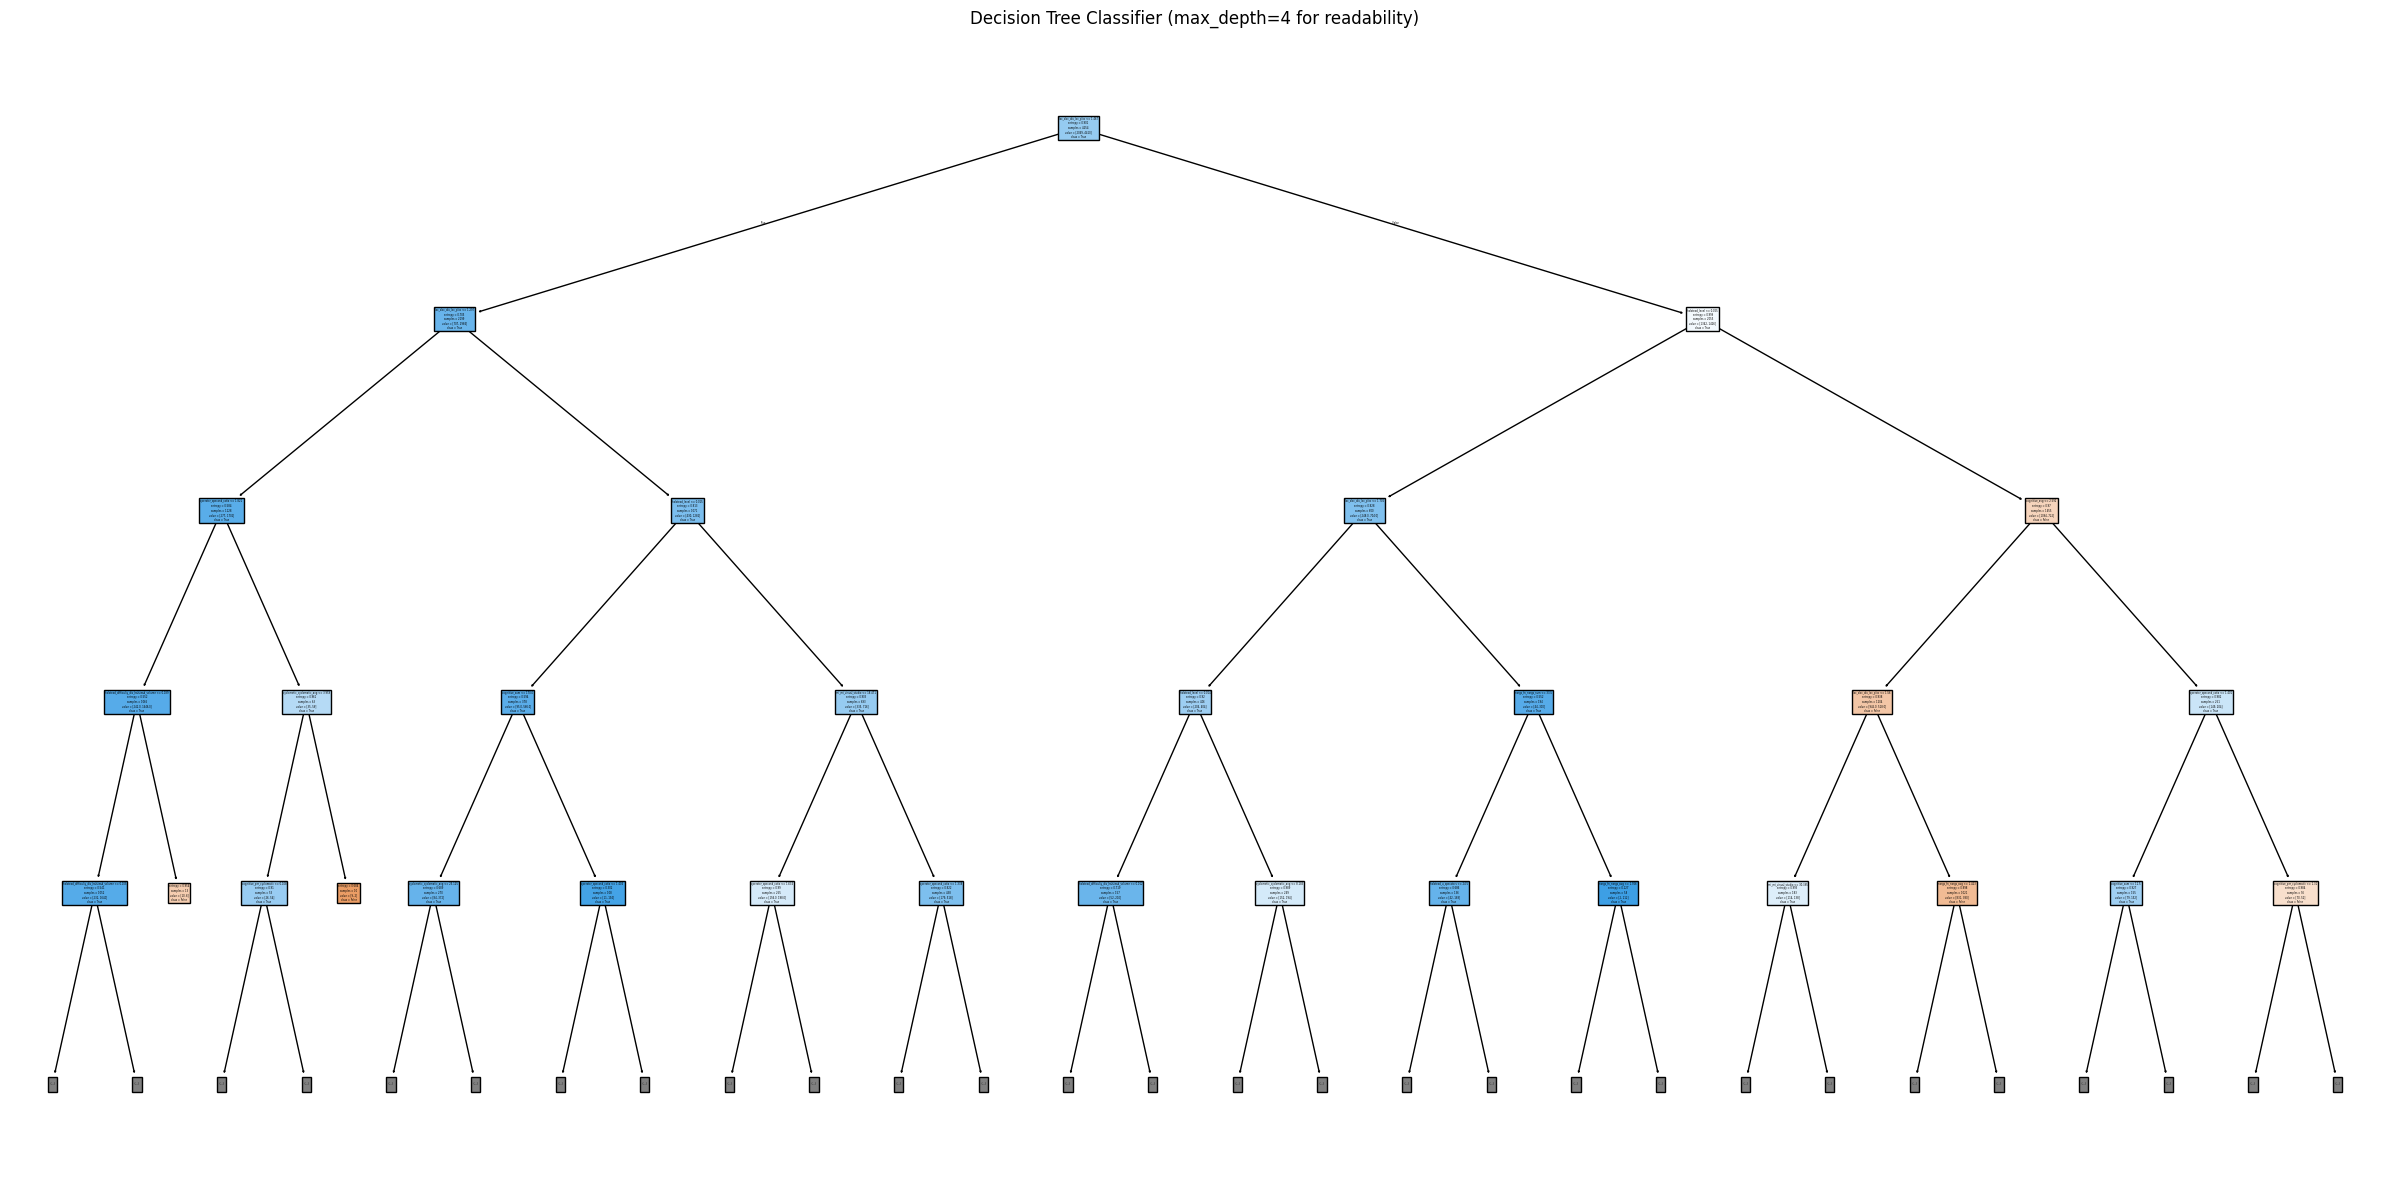

Tree visualization saved to decision_tree_optimized.png


In [10]:

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(dt_clf, feature_names=list(X_final.columns),
          class_names=list(le.classes_), filled=True, ax=ax, max_depth=4)
plt.title("Decision Tree Classifier (max_depth=4 for readability)")
plt.tight_layout()
plt.savefig("decision_tree_optimized.png", dpi=150, bbox_inches='tight')
plt.show()
print("Tree visualization saved to decision_tree_optimized.png")

In [11]:

print("\n" + "="*60)
print("EXTRACTING DECISION TREE RULES (INTERPRETABLE)")
print("="*60)

tree_rules = export_text(dt_clf, feature_names=list(X_final.columns), max_depth=4)
print("Decision Tree Rules (first 4 levels):")
print(tree_rules)


EXTRACTING DECISION TREE RULES (INTERPRETABLE)
Decision Tree Rules (first 4 levels):
|--- loc_sloc_div_loc_ploc <= 1.47
|   |--- loc_sloc_div_loc_ploc <= 1.30
|   |   |--- operator_operand_ratio <= 1.82
|   |   |   |--- halstead_difficulty_div_halstead_volume <= 0.04
|   |   |   |   |--- halstead_difficulty_div_halstead_volume <= 0.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- halstead_difficulty_div_halstead_volume >  0.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- halstead_difficulty_div_halstead_volume >  0.04
|   |   |   |   |--- class: 0
|   |   |--- operator_operand_ratio >  1.82
|   |   |   |--- cyclomatic_cyclomatic_avg <= 3.96
|   |   |   |   |--- cognitive_per_cyclomatic <= 0.11
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- cognitive_per_cyclomatic >  0.11
|   |   |   |   |   |--- class: 1
|   |   |   |--- cyclomatic_cyclomatic_avg >  3.96
|   |   |   |   |--- class: 0
|   |--- loc_sloc_div_loc_ploc >  1.30
|   |   |--- halstead_level <= 0.02
|  


MODEL COMPARISON


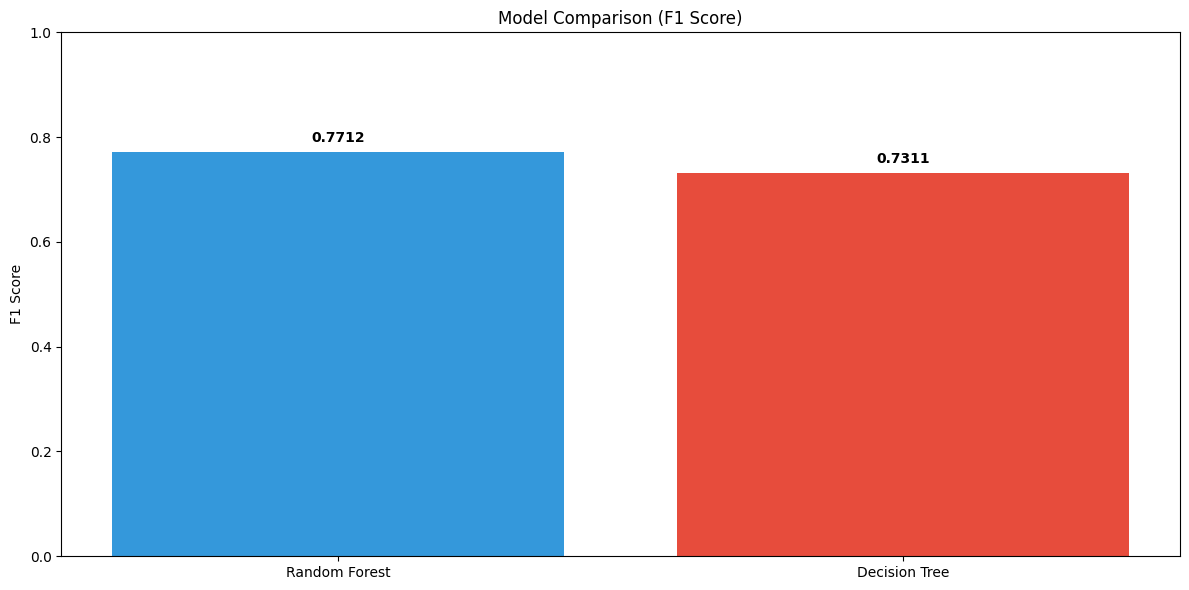

In [12]:

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

plt.figure(figsize=(12, 6))
models = ['Random Forest', 'Decision Tree']
f1_scores_plot = [rf_f1_scores.mean(), dt_f1_scores.mean()]
colors = ['#3498db', '#e74c3c']

plt.bar(models, f1_scores_plot, color=colors)
plt.ylabel('F1 Score')
plt.title('Model Comparison (F1 Score)')
plt.ylim(0, 1)
for i, v in enumerate(f1_scores_plot):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Original features: {X.shape[1]}")
print(f"Enhanced features: {X_enhanced.shape[1]}")
print(f"Selected features: {X_final.shape[1]}")
print(f"\nRandom Forest F1: {rf_f1_scores.mean():.4f} (+/- {rf_f1_scores.std():.4f})")
print(f"Decision Tree F1: {dt_f1_scores.mean():.4f} (+/- {dt_f1_scores.std():.4f})")

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)

print("\nFinal Feature Set:")
print(X_final.columns.tolist())


SUMMARY
Original features: 54
Enhanced features: 107
Selected features: 30

Random Forest F1: 0.7712 (+/- 0.0539)
Decision Tree F1: 0.7311 (+/- 0.0252)

OPTIMIZATION COMPLETE

Final Feature Set:
['nargs_fn_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_max', 'cognitive_sum', 'cognitive_avg', 'cognitive_max', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_max', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_level', 'loc_blank', 'mi_mi_visual_studio', 'operator_operand_ratio', 'cognitive_per_cyclomatic', 'halstead_difficulty_div_halstead_volume', 'loc_sloc_div_loc_ploc', 'halstead_difficulty_high', 'halstead_difficulty_low', 'loc_sloc_high', 'halstead_effort_high', 'halstead_effort_low', 'cognitive_sum_high', 'cognitive_sum_low', 'halstead_difficulty_outlier', 'loc_sloc_outlier', 'halstead_effort_outlier', 'cognitive_sum_outlier']
